## Import of Libraries

In [1]:
# Import visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Import data handling libraries
import pandas as pd
import numpy as np
from numpy.linalg import norm
import pickle

# Import machine learning libraries
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

## Configuration of Display Options

In [2]:
# Set display format for floats to 2 decimal places
pd.set_option("display.float_format", "{:,.2f}".format)

## Loading of Dataset

In [3]:
# Import preprocessor
with open("../data/processed/preprocessor.pkl", "rb") as f:
    preprocessor = pickle.load(f)

# Import filtered DataFrame
with open("../data/processed/df_filtered.pkl", "rb") as f:
    df_filtered = pickle.load(f)

# Import preprocessed DataFrame
with open("../data/processed/df_preprocessed.pkl", "rb") as f:
    df_preprocessed = pickle.load(f)

# Import feature names
with open("../data/processed/feature_names.pkl", "rb") as f:
    feature_names = pickle.load(f)

In [4]:
# Plot names of preporcessed features
display("Preprocessed Features")
for name in feature_names: 
    print(name)

'Preprocessed Features'

minmax__popularity
standard__duration_min
standard__loudness
standard__tempo
standard__power_score
standard__chill_score
standard__groove
cat__track_genre_ambient
cat__track_genre_breakbeat
cat__track_genre_chicago-house
cat__track_genre_club
cat__track_genre_dance
cat__track_genre_deep-house
cat__track_genre_drum-and-bass
cat__track_genre_dubstep
cat__track_genre_edm
cat__track_genre_electro
cat__track_genre_electronic
cat__track_genre_hardstyle
cat__track_genre_house
cat__track_genre_idm
cat__track_genre_minimal-techno
cat__track_genre_progressive-house
cat__track_genre_synth-pop
cat__track_genre_techno
cat__track_genre_trance
cat__camelot_id_10A
cat__camelot_id_10B
cat__camelot_id_11A
cat__camelot_id_11B
cat__camelot_id_12A
cat__camelot_id_12B
cat__camelot_id_1A
cat__camelot_id_1B
cat__camelot_id_2A
cat__camelot_id_2B
cat__camelot_id_3A
cat__camelot_id_3B
cat__camelot_id_4A
cat__camelot_id_4B
cat__camelot_id_5A
cat__camelot_id_5B
cat__camelot_id_6A
cat__camelot_id_6B
cat__camelot_id

## Baseline Model: k-Means

### Instantiate Model

In [5]:
# Instantiate basline model (with high numer of classifications)
model_km = KMeans(
    n_clusters=3000,
    random_state=42
)

### Organize Data in Feature Matrix

In [6]:
# Select columns for feature selection
selected_exact = [
    "raw__danceability",
    "raw__energy",
    "remainder__speechiness",
    "raw__instrumentalness",
    "raw__valence",
    "standard__tempo",
]

camelot_prefix = "cat__camelot__id_"

# Create masks for filtering data
mask_exact = np.isin(feature_names, selected_exact)
mask_camelot = np.char.startswith(feature_names.astype(str), camelot_prefix)

mask = mask_exact | mask_camelot

# Perform feature selection
df_features_selected = df_preprocessed.loc[:, mask]

df_features_selected

,standard__tempo,raw__energy,raw__danceability,raw__instrumentalness,raw__valence,remainder__speechiness
4000,-1.39,0.40,0.45,0.85,0.33,0.03
4001,-1.94,0.30,0.52,0.46,0.23,0.03
4002,-1.35,0.47,0.37,0.57,0.18,0.03
4003,0.64,0.40,0.41,0.68,0.16,0.03
4004,-1.27,0.51,0.45,0.77,0.12,0.03
...,...,...,...,...,...,...
110994,0.52,0.99,0.39,0.98,0.37,0.07
110995,0.52,0.99,0.15,0.94,0.09,0.09
110996,0.52,0.98,0.50,0.92,0.38,0.05
110997,0.93,0.99,0.47,0.37,0.06,0.10


### Adjust Model to Data

In [7]:
# Fit model
model_km.fit(df_features_selected)

,n_clusters,3000
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [8]:
# Evaluate quality of selected number of clusters using WCSS (Within-cluster sum of squares)
display("WCSS (Within-cluster sum of squares)")
model_km.score(df_features_selected)

'WCSS (Within-cluster sum of squares)'

-117.67518687367654

In [9]:
# Predict classifications and add labels
labels_km = model_km.labels_  # prediction
df_filtered["label_km"] = labels_km

# Show value count 
display("Value Counts of Labels")
df_filtered["label_km"].value_counts()

'Value Counts of Labels'

label_km
368     57
224     53
1407    48
613     44
215     43
        ..
2034     1
1071     1
1740     1
1920     1
2179     1
Name: count, Length: 3000, dtype: int64

In [10]:
# Determine the Euclidean distances
distances_train = model_km.transform(df_features_selected) # Alternative: distances = euclidean_distances(X_train, model_km.cluster_centers_)

### Create Track Recommendations

In [11]:
# Create recommendations based on a selected track
row    = 73498     
n_max  = 10

pos_ref = df_features_selected.index.get_loc(row)
cluster = labels_km[pos_ref]

mask_cluster   = (labels_km == cluster)
cluster_labels = df_features_selected.index[mask_cluster].tolist()

others = [i for i in cluster_labels if i != row] # Skip self-match
cluster_labels = [row] + others

subset = [row] + others[:n_max]

print(f"Cluster-ID (k-means): {cluster}")
print(f"Number of similar Tracks: {len(others)}")

display(df_filtered.loc[subset])

Cluster-ID (k-means): 2822
Number of similar Tracks: 4


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,camelot_id,power_score,vocal_score,party_score,chill_score,club_factor,groove,popularity_label,tempo_label,label_km
73498,1E8eEIQp098hKFRhh1RaWs,Dominik Eulberg,Diorama,Wenn Es Perlen Regnet,21,502196,0,0.70,0.66,7,...,9A,-3.07,0.00,0.21,8.37,0.46,512.03,Underground,128–140 Techno/Trance,2822
13266,6fTRGy6yAkPNLTamKb1LEg,Phuture,We Are Phuture,Slam,11,338307,0,0.67,0.60,11,...,1B,-3.90,0.01,0.23,9.11,0.40,506.25,Underground,124–128 House,2822
13866,4xT1xuISyiQfN9G796Fq61,Phuture,We Are Phuture,Slam,5,338333,0,0.67,0.61,7,...,9A,-3.81,0.01,0.22,9.10,0.41,506.24,Unknown,124–128 House,2822
73525,11ZQGqpwvDNrw9HUoxGLhy,Claude VonStroke,Bird Brain,Aundy - DJ Version,20,412493,0,0.72,0.58,0,...,8B,-3.69,0.00,0.28,8.00,0.42,504.02,Underground,124–128 House,2822
73816,5oPxB39cGr0cn2GjSzrSt2,Alan Fitzpatrick,U Said U,U Said U,18,395775,0,0.68,0.65,10,...,6B,-2.43,0.00,0.21,6.89,0.44,507.95,Underground,124–128 House,2822


### Evaluation of Model Quality

'Finding the best value for k'

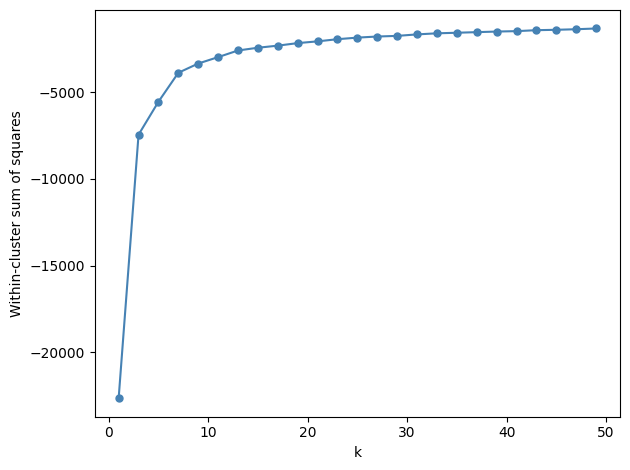

In [12]:
# Determining k: Elbow-Method
# Find the best number of clusters
cluster_scores = []
for n_cluster in range(1, 50, 2):
    model = KMeans(n_clusters=n_cluster, random_state=42)
    model.fit(df_features_selected)
    cluster_scores.append(model.score(df_features_selected))

display("Finding the best value for k")
fig, ax = plt.subplots()
ax.plot(range(1, 50, 2), 
        cluster_scores, 
        marker='o', 
        markersize=5,
        color="steelblue")
ax.set_xlabel("k")
ax.set_ylabel("Within-cluster sum of squares")

plt.tight_layout()

In [13]:
# Interpretation of clusters
display("Mean values and standard deviations for different n_init")

for n_init in [1, 10, 20, 30, 40]:
    cluster_scores = []
    for i in range(10):
        model = KMeans(
            n_clusters=7, 
            n_init=n_init)
        model.fit(df_features_selected)
        cluster_scores.append(model.score(df_features_selected))
    print(np.mean(cluster_scores), np.std(cluster_scores))

'Mean values and standard deviations for different n_init'

-3928.90560052925 63.78480326224603
-3886.6376321078324 1.4124643860453383
-3886.0049545137567 1.1819611751582768
-3885.418618859777 0.051716106855180195
-3885.3873287382276 0.019443911736067163


In [14]:
# Determine Silhouette Score
display("Silhouette Score")
silhouette_score(
    X=df_features_selected, 
    labels=model_km.labels_,
    metric='euclidean'
)

'Silhouette Score'

0.28643752225855323

'Silhouette coefficients for k-Means with k = 7'

/Users/Steffen/Documents/01_Beschäftigung/Weiterbildung/Data Science/StackFuel/Kurse/05_Projekt-Portfoliokurs (DPP)/Portfolio Project/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


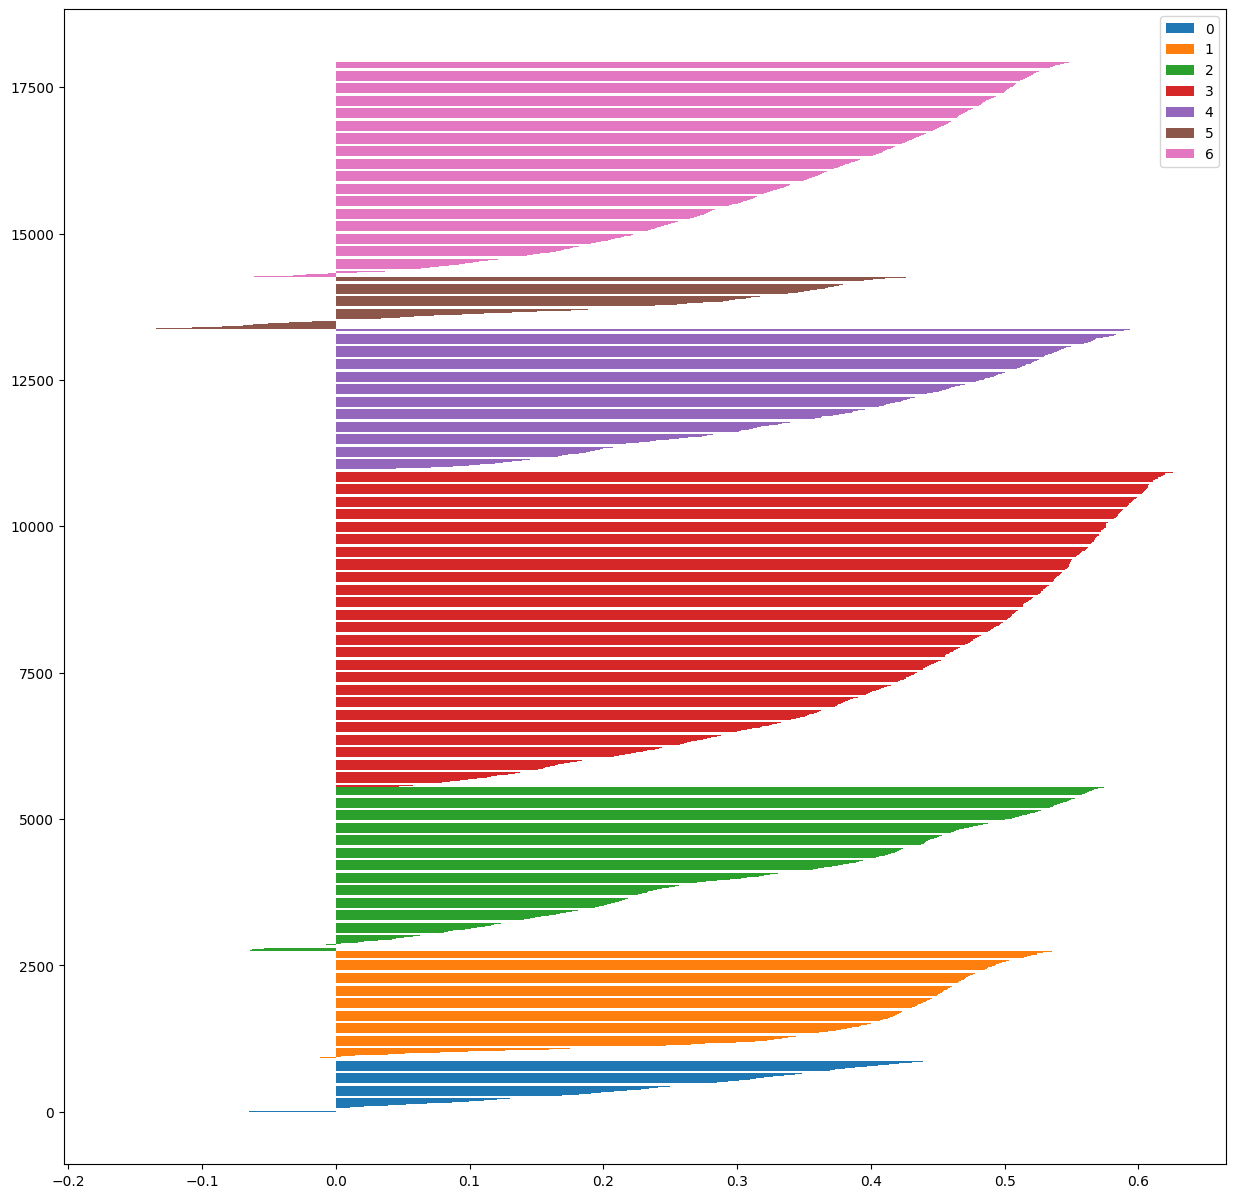

In [15]:
# Determine Silhouette coefficients for k-Means
arr_sil = silhouette_samples(
    X=df_features_selected, 
    labels=model.labels_, 
    metric="euclidean"
)

display("Silhouette coefficients for k-Means with k = 7")

fig, ax = plt.subplots(figsize=(15, 15))
start = 0
end = 0

for cluster in np.unique(model.labels_):
    mask = model.labels_ == cluster
    sv_len = len(arr_sil[mask])
    sv_sorted = np.sort(arr_sil[mask])
#    if any(x < 0 for x in sv_sorted) == False: 
#        print('Cluster:', cluster)
    end = end + sv_len
    ax.barh(range(start, end), width=sv_sorted, label = cluster)
    start = end

ax.legend()
plt.show()

### Insights:



## Additional Model: DBSCAN

### Instantiate Model

In [16]:
# Instantiate additional 
model_db = DBSCAN(
    eps=0.1,
    min_samples=5,  
    leaf_size=10
)

### Organize Data in Feature Matrix

In [17]:
df_features_selected

,standard__tempo,raw__energy,raw__danceability,raw__instrumentalness,raw__valence,remainder__speechiness
4000,-1.39,0.40,0.45,0.85,0.33,0.03
4001,-1.94,0.30,0.52,0.46,0.23,0.03
4002,-1.35,0.47,0.37,0.57,0.18,0.03
4003,0.64,0.40,0.41,0.68,0.16,0.03
4004,-1.27,0.51,0.45,0.77,0.12,0.03
...,...,...,...,...,...,...
110994,0.52,0.99,0.39,0.98,0.37,0.07
110995,0.52,0.99,0.15,0.94,0.09,0.09
110996,0.52,0.98,0.50,0.92,0.38,0.05
110997,0.93,0.99,0.47,0.37,0.06,0.10


### Adjust Model to Data

In [18]:
# Fit model
model_db.fit(df_features_selected)

,eps,0.1
,min_samples,5
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,10
,p,None
,n_jobs,None


In [19]:
# Predict classifications and add labels
labels_db = model_db.labels_  # prediction
df_filtered["label_db"] = labels_db

# Show value count 
display("Value Counts of Labels")
df_filtered["label_db"].value_counts()

'Value Counts of Labels'

label_db
-1      7760
 1      4905
 2      1698
 4      1026
 17      317
        ... 
 184       4
 148       4
 192       3
 129       3
 205       3
Name: count, Length: 207, dtype: int64

### Create Track Recommendations

In [20]:
# Create recommendations based on a selected track
row  = 73498
n_max  = 10

pos_ref   = df_features_selected.index.get_loc(row)
cluster   = labels_db[pos_ref]

if cluster == -1:
    print("Reference track is in noise (-1). There is no corresponding Cluster.")
else:
    mask_cluster   = (labels_db == cluster)
    cluster_labels = df_features_selected.index[mask_cluster].tolist()
    
    cluster_labels = [row] + [i for i in cluster_labels if i != row] # Skip self-match
    subset = cluster_labels[: (1 + n_max)]

    print(f"Cluster-ID (DBSCAN): {cluster}")
    print(f"Number of similar Tracks: {len(cluster_labels)}")

    display(df_filtered.loc[subset])


Cluster-ID (DBSCAN): 2
Number of similar Tracks: 1698


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,power_score,vocal_score,party_score,chill_score,club_factor,groove,popularity_label,tempo_label,label_km,label_db
73498,1E8eEIQp098hKFRhh1RaWs,Dominik Eulberg,Diorama,Wenn Es Perlen Regnet,21,502196,0,0.70,0.66,7,...,-3.07,0.00,0.21,8.37,0.46,512.03,Underground,128–140 Techno/Trance,2822,2
4036,6QzdmoHqSH08FOq18fxqKd,Bicep,Tsugi Chill-Out,Atlas,1,348306,0,0.55,0.79,3,...,-1.34,0.00,0.07,6.15,0.43,515.91,Unknown,128–140 Techno/Trance,2353,2
4154,4WyhOKXtCkNVcgfTBpYaxm,Christian Löffler,Ronda,Ronda,57,346586,0,0.79,0.31,3,...,-4.47,0.00,0.14,12.89,0.24,479.98,Hit,110–124 Midtempo,1755,2
4225,0WfOuXw05LJq4ik1lVvTzi,Bicep,Isles,Apricots,63,246506,0,0.82,0.60,11,...,-1.60,0.01,0.40,3.28,0.49,511.94,Hit,124–128 House,2930,2
4233,4ho6jJU2nbX0NbiF33i4tX,Jon Hopkins;Kelly Lee Owens;Sultan + Shepard;J...,To Feel Again / Trois,To Feel Again / Trois,58,293489,0,0.50,0.87,4,...,-1.63,0.00,0.02,7.31,0.43,520.00,Hit,128–140 Techno/Trance,309,2
4262,3VtTuQ6lypMoOBcm6VMzdh,Bicep;Four Tet,Opal (Four Tet Remix),Opal - Four Tet Remix,58,494256,0,0.83,0.72,9,...,-2.34,0.03,0.24,5.83,0.59,508.04,Hit,124–128 House,1734,2
4660,73X9X7kDgsm4YeHpc8prf6,Bicep,Apricots,Apricots,54,246506,0,0.82,0.60,11,...,-1.60,0.01,0.40,3.28,0.49,511.94,Popular,124–128 House,2930,2
4704,0E5kJzyQhf4m02ooeO9tTy,AL-90;FMSAO,Hibernation,Vchera,43,323000,0,0.65,0.61,8,...,-2.21,0.01,0.12,7.20,0.40,479.97,Popular,110–124 Midtempo,967,2
4712,7rDZ4nCDVmaKrJeJacR0ih,Fejká;Marie Angerer,Infinity,Infinity (feat. Marie Angerer),45,252633,0,0.58,0.55,9,...,-3.40,0.00,0.04,10.75,0.32,480.09,Popular,110–124 Midtempo,710,2
4742,6Xw5vTsRaUPaJO8mL0lUzh,Bicep,Water,Apricots,46,246506,0,0.82,0.60,11,...,-1.61,0.01,0.39,3.22,0.49,511.96,Popular,124–128 House,2930,2


### Evaluation of Model Quality

'Distribution of Distances to the Nearest Neighbor'

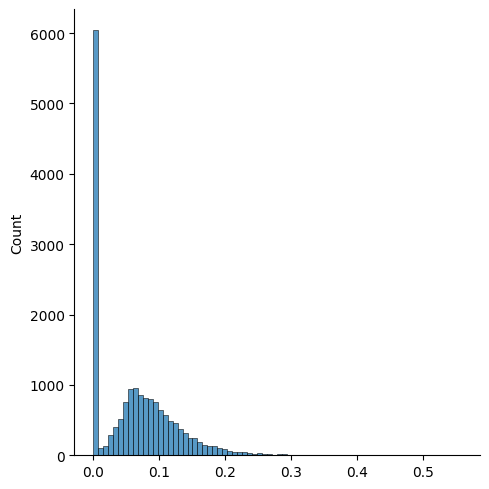

In [21]:
# Determine distances between data points
arr_dist = euclidean_distances(df_features_selected)
arr_dist_sorted = np.sort(arr_dist, axis=1)

# Plot distribution of distances to the nearest neighbor
display("Distribution of Distances to the Nearest Neighbor")
sns.displot(arr_dist_sorted[:, 1], kde=False)

'Sorted Distances to 12th Neighbor'

[Text(0.5, 0, 'Data points'), Text(0, 0.5, 'Distance to 12th Neighbor')]

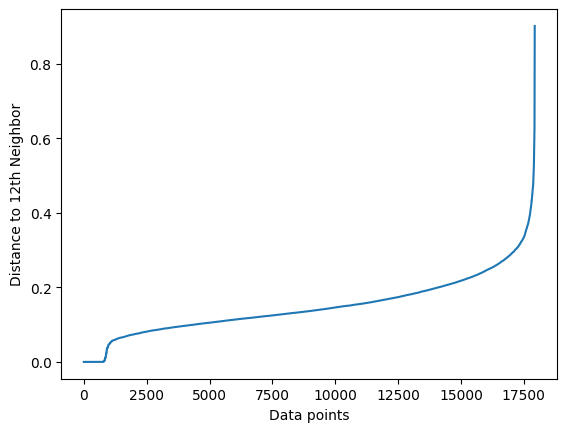

In [22]:
# Create a k-distance plot (Distances to nearest neighbors)
display("Sorted Distances to 12th Neighbor")
fig, ax = plt.subplots()

ax.plot(range(len(arr_dist_sorted)), np.sort(arr_dist_sorted[:, 12]))  # min_sampels = 2 x num_of_dimensions
ax.set(xlabel='Data points', ylabel='Distance to 12th Neighbor')

In [23]:
# Determine maximum distance eps
np.sort(arr_dist_sorted[:, 12])[17000]

np.float64(0.2899432244192542)

In [24]:
# Instantiate model with optimized hyperparameters
model = DBSCAN(
    eps=0.29, 
    min_samples=12)

# Fit model
model.fit(df_features_selected)

# Clusternamen
np.unique(model.labels_)

array([-1,  0])

In [25]:
# Calculate sum of outliers
np.sum(model.labels_ == -1)

np.int64(248)

'Cluster Assignment (Dimensionality reduced)'

/Users/Steffen/Documents/01_Beschäftigung/Weiterbildung/Data Science/StackFuel/Kurse/05_Projekt-Portfoliokurs (DPP)/Portfolio Project/.venv/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


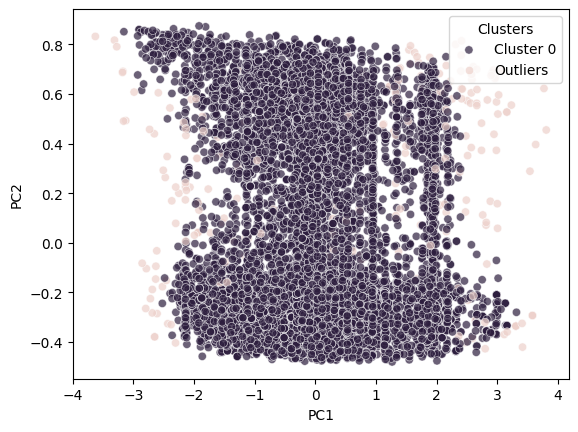

In [26]:
# Show cluster assignment (dimensionality reduced)
#pca
pca = PCA(n_components=2)
cluster_plot_arr = pca.fit_transform(df_features_selected)

#plot
display("Cluster Assignment (Dimensionality reduced)")
ax = sns.scatterplot(x=cluster_plot_arr[:,0],
                     y=cluster_plot_arr[:,1],
                     alpha=0.7,
                     hue=model.labels_)

#style plot
ax.set(xlabel='PC1',
       ylabel='PC2')

#configure legend
plt.legend(title='Clusters',
           labels=['Cluster 0','Outliers']);

'Silhouette coefficients for DBSCAN'

/Users/Steffen/Documents/01_Beschäftigung/Weiterbildung/Data Science/StackFuel/Kurse/05_Projekt-Portfoliokurs (DPP)/Portfolio Project/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


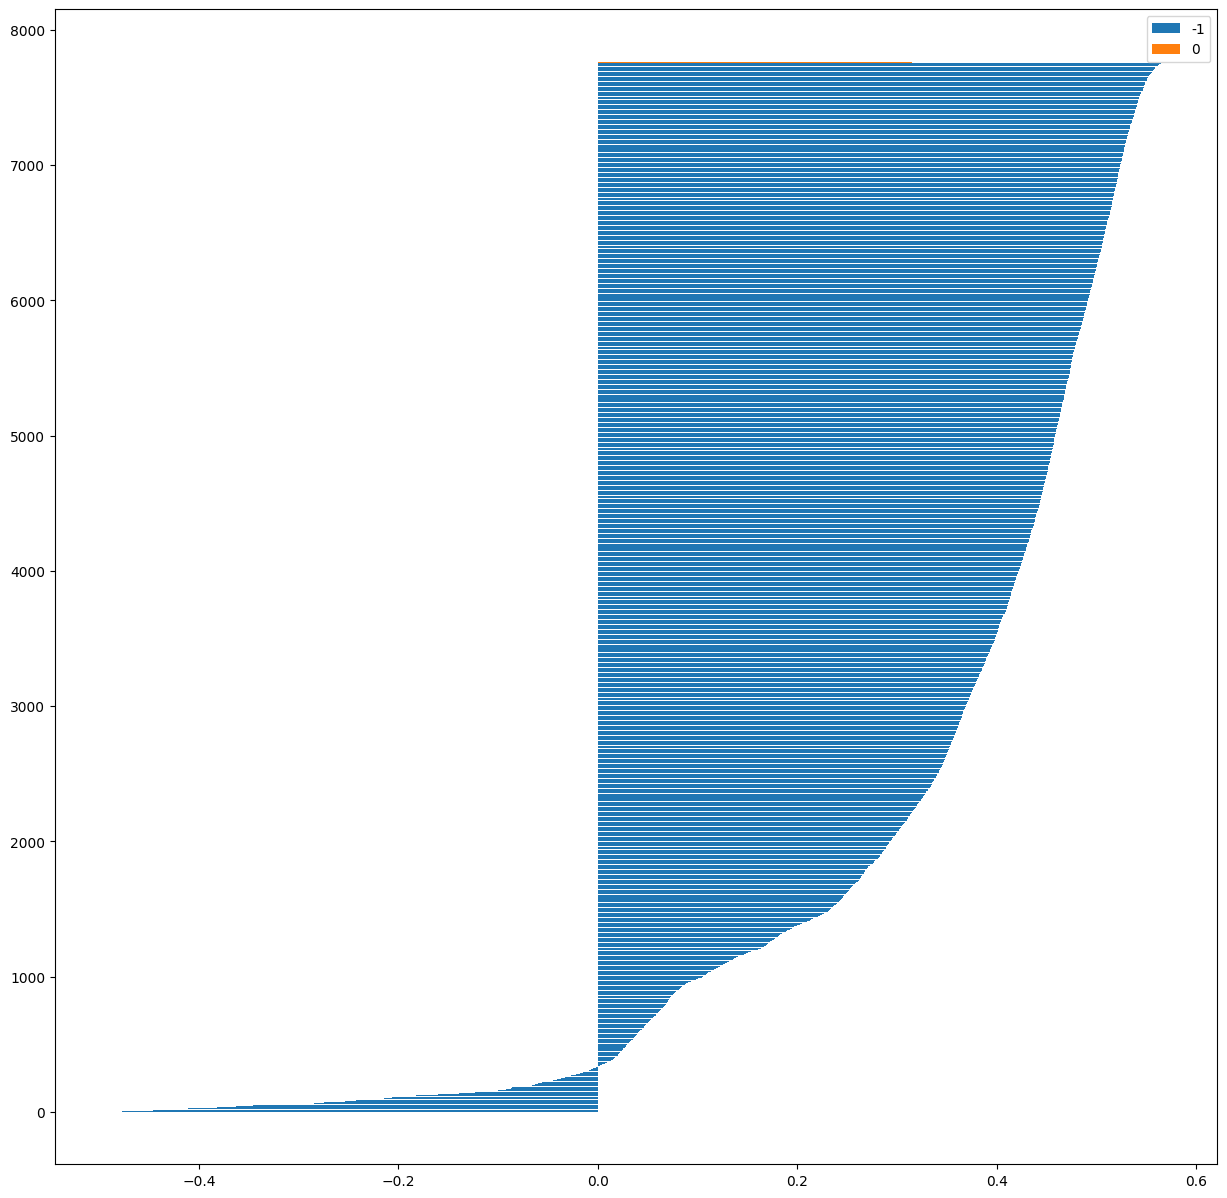

In [27]:
# Determine Silhouette coefficients from DBSCAN 
arr_sil = silhouette_samples(
    X=df_features_selected, 
    labels=model.labels_, 
    metric="euclidean"
)

display("Silhouette coefficients for DBSCAN")

fig, ax = plt.subplots(figsize=[15, 15])
start = 0  
end = 0

for cluster in np.unique(model.labels_):
    mask = model_db.labels_ == cluster
    sv_len = len(arr_sil[mask])
    sv_sorted = np.sort(arr_sil[mask])
    end = end + sv_len
    ax.barh(range(start, end), width=sv_sorted, label=cluster)
    start = end
    
ax.legend()
plt.show()

### Insights:



## Alternative Calculation: Cosine-Similarity

### Function for Track Recommendation

In [28]:
# Create Function to collect tracks identified as similar in a list
def track_recommendation(df_features_selected, row, sim_min):
    """
    Return labels of tracks in df_features_selected that are similar to the track with index `label`.

    Cosine similarity is used as the measure of likeness between two tracks.

    Args:
        df_features_selected (DataFrame): Numeric feature matrix (already scaled/engineered).
        label (hashable): Index label in df_features_selected of the reference track 
                          (e.g. 4000, 4001 oder eine Spotify-ID falls als Index gesetzt).
        sim_min (float): Minimum cosine similarity (between -1 and 1).

    Returns:
        recommendations (list[hashable]): Index labels of tracks with similarity >= sim_min.
    """
    columns = df_features_selected.columns
    recommendations = []

    v_ref = df_features_selected.loc[row, columns].to_numpy()

    for i in df_features_selected.index:
        if i == row:
            continue  # Skip self-match

        v_i = df_features_selected.loc[i, columns].to_numpy()
        dot_product  = np.dot(v_ref, v_i)
        norm_product = norm(v_ref) * norm(v_i)
        similarity   = dot_product / (norm_product + 1e-12)  # Protection against division by 0

        if similarity >= sim_min:
            recommendations.append(i)

    return recommendations

### Create Track Recommendations

In [29]:
# Create recommendations based on a minimum similarity of 0.998
row = 73498
sim_min = 0.998

cs_selected_row = track_recommendation(df_features_selected, row, sim_min)

print(f"Number of similar Tracks:", len(cs_selected_row))

rows_with_ref = [row] + cs_selected_row 

display(df_filtered.loc[rows_with_ref])

Number of similar Tracks: 5


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,power_score,vocal_score,party_score,chill_score,club_factor,groove,popularity_label,tempo_label,label_km,label_db
73498,1E8eEIQp098hKFRhh1RaWs,Dominik Eulberg,Diorama,Wenn Es Perlen Regnet,21,502196,0,0.70,0.66,7,...,-3.07,0.00,0.21,8.37,0.46,512.03,Underground,128–140 Techno/Trance,2822,2
13866,4xT1xuISyiQfN9G796Fq61,Phuture,We Are Phuture,Slam,5,338333,0,0.67,0.61,7,...,-3.81,0.01,0.22,9.10,0.41,506.24,Unknown,124–128 House,2822,2
29203,5hlxswETS4FB4oCg6g7JHk,Manila Killa;Nick Lopez;San Holo,Mean It,Mean It,47,218728,0,0.66,0.55,4,...,-2.19,0.01,0.15,6.26,0.36,508.06,Popular,124–128 House,2171,-1
73791,3OTjLe48w7jfPG2GNLfD6K,Traumer;Madben,ADN RETROSPECTIVE (Part.1),Underlying - Madben Remix,0,401977,0,0.74,0.67,7,...,-2.34,0.01,0.18,7.22,0.49,507.99,Unknown,124–128 House,2976,2
73816,5oPxB39cGr0cn2GjSzrSt2,Alan Fitzpatrick,U Said U,U Said U,18,395775,0,0.68,0.65,10,...,-2.43,0.00,0.21,6.89,0.44,507.95,Underground,124–128 House,2822,2
109707,5qLZvk6aOHiP7ojmSVuCq0,Zimmz,Sinematic,Sinematic,41,420000,0,0.66,0.68,7,...,-2.43,0.00,0.16,7.39,0.45,508.00,Aspiring,124–128 House,2976,2


### Insights: